# 09 — Fair lending and the real loan market

Every loan in the project so far has been simulated. This notebook brings in 32,926 real mortgage applications from the same metropolitan area, taken from the public Home Mortgage Disclosure Act (HMDA) file, which records the decision, the loan terms, and the applicant's race, ethnicity and sex. Notebook 04 tested the AVM for error parity across neighbourhoods but could not run a fair-lending test, because the Ames sales file has no protected-class attribute; HMDA makes that test possible on the lending side. Holding the recorded underwriting factors constant, Black applicants face 1.98× the odds of denial of white applicants and Hispanic or Latino applicants 1.65× (§3), and an E-value (§4) measures how strong the missing credit score would have to be to explain that away. Collateral, the appraised or modelled value of the house, is cited in one denial in six (§5), which ties the lending data back to the notebook 03 valuation model, and the real loan-to-value distribution looks nothing like the flat 80% book assumed in notebook 08 (§6).

Terms are defined in [the glossary](../docs/GLOSSARY.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter

from ames.compat import silence_spurious_matmul_warnings
from ames.data import HMDA_MSA, HMDA_YEARS, load_hmda
from ames.fairlending import (DENIAL_REASONS, MIN_GROUP_FOR_MODEL, NOT_A_GROUP,
                              POOLED_LABEL, adjusted_disparity, decisioned,
                              denial_rates, denial_reason_mix, dti_band, e_value,
                              ltv_distribution)
from ames.viz import (AQUA, BLUE, CONTEXT, CONTEXT_DARK, CONTRAST, CONTRAST_FILL,
                      GRID, INK_MUTED, INK_SECONDARY, ORANGE, PANEL, STATUS,
                      SUBJECT, SUBJECT_FILL, SURFACE, annotate, axis_note,
                      bar_labels, callout, fig_titled, label_end, legend_above,
                      money, pct, pct1, reference_line, save, use_style)

use_style()
silence_spurious_matmul_warnings()
pd.set_option("display.width", 165)

KICKER = "09 · Fair lending"
SOURCE = ("Source: CFPB HMDA Data Browser · Ames, IA MSA (11180) · "
          f"{HMDA_YEARS[0]}-{HMDA_YEARS[-1]}.")

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

hmda = load_hmda()
apps = decisioned(hmda)

print(f"{len(hmda):,} filings, {HMDA_YEARS[0]}-{HMDA_YEARS[-1]}, MSA {HMDA_MSA}")
print(f"{len(apps):,} of them carry a credit decision")
print(f"overall denial rate: {apps['denied'].mean():.1%}")

32,926 filings, 2018-2024, MSA 11180
25,203 of them carry a credit decision
overall denial rate: 11.7%


## 1. What this file is, and what it cannot answer

Every mortgage lender above a size threshold must report every application it receives. The public file is the result: one row per application, with the outcome, the loan terms, and the applicant's race, ethnicity and sex.

Three exclusions are made before anything is computed, and each changes the answer:

| Excluded | Why |
|---|---|
| `action_taken == 6`, purchased loans | Another lender's origination, bought on the secondary market. No decision was made here, and counting them as approvals drags every denial rate toward zero. |
| Withdrawn and incomplete files | The applicant stopped, not the lender. Whether these belong in a denial rate is arguable; excluding them is the conservative choice, because withdrawals cluster in files that were heading for denial. |
| "Race not available" | Missing data recorded as a category. It stays in the descriptive table, flagged, and out of the model. |

One thing this file does **not** contain matters more than everything above: **a credit score.** There are also no assets, reserves, employment history or property condition. Section 4 examines what that absence does to every number in section 3.

In [2]:
outcomes = (hmda["action_taken"].value_counts().rename("filings").to_frame())
outcomes.index = outcomes.index.map({
    1: "1 · originated", 2: "2 · approved, not accepted", 3: "3 · denied",
    4: "4 · withdrawn by applicant", 5: "5 · closed for incompleteness",
    6: "6 · purchased loan (another lender's)", 7: "7 · preapproval denied",
    8: "8 · preapproval approved, not accepted"})
outcomes["share"] = outcomes["filings"] / len(hmda)
outcomes["in scope"] = ["yes" if i.startswith(("1 ", "2 ", "3 ")) else "no"
                        for i in outcomes.index]
outcomes.sort_index()

,filings,share,in scope
action_taken,,,
1 · originated,21752,0.660633,yes
"2 · approved, not accepted",508,0.015429,yes
3 · denied,2943,0.089382,yes
4 · withdrawn by applicant,3309,0.100498,no
5 · closed for incompleteness,883,0.026818,no
6 · purchased loan (another lender's),3475,0.105540,no
7 · preapproval denied,18,0.000547,no
"8 · preapproval approved, not accepted",38,0.001154,no


  saved reports/figures/09_hmda_volume.png


/Users/mohona/DS/Portfolio/real-estate-valuation-risk/src/ames/viz.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


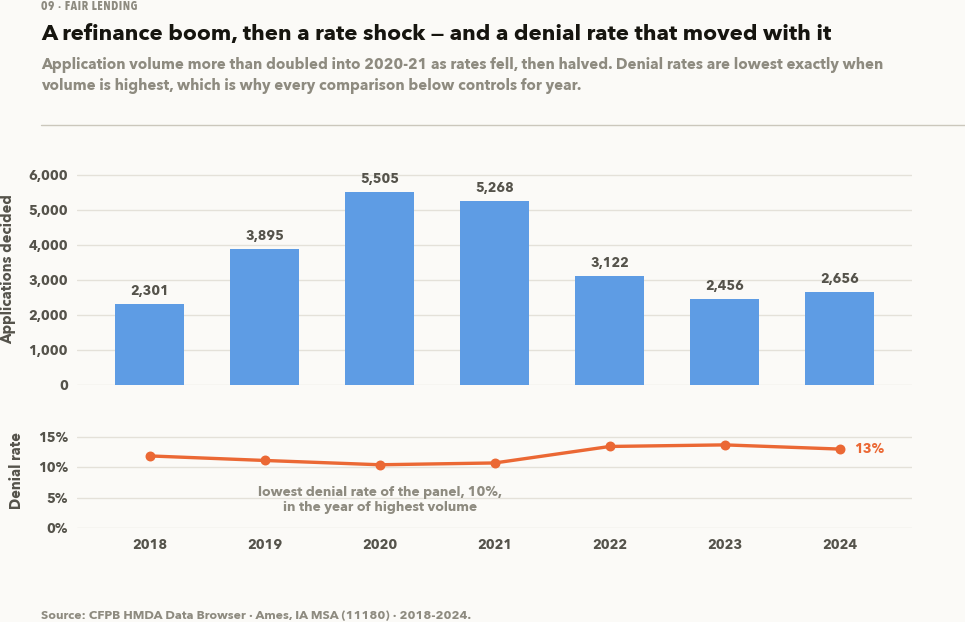

In [3]:
volume = (apps.groupby("activity_year")
          .agg(applications=("denied", "size"), denial_rate=("denied", "mean")))

# Two panels sharing one x axis, not one panel with two y axes.  A dual-axis chart
# lets whoever drew it choose the scales, and therefore choose whether the lines
# appear to move together.  Stacking them removes that freedom.
fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(9.8, 6.2), sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.0], "hspace": 0.16})

bars = top.bar(volume.index, volume["applications"], color=SUBJECT_FILL, width=0.6)
top.set_ylabel("Applications decided")
top.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
# ax.bar_label, not the repo's bar_labels: that helper is for horizontal bars.
top.bar_label(bars, labels=[f"{v:,}" for v in volume["applications"]],
              padding=4, fontsize=8.8, color=INK_SECONDARY)
top.margins(y=0.20)

bottom.plot(volume.index, volume["denial_rate"], color=CONTRAST, lw=2.2,
            marker="o", ms=5.5)
bottom.set_ylim(0, 0.19)
bottom.set_ylabel("Denial rate")
bottom.yaxis.set_major_formatter(pct)
bottom.set_xticks(list(volume.index))
bottom.margins(x=0.07)
label_end(bottom, volume.index[-1], volume["denial_rate"].iloc[-1],
          f"{volume['denial_rate'].iloc[-1]:.0%}", color=CONTRAST)
annotate(bottom, volume["denial_rate"].idxmin(), volume["denial_rate"].min(),
         f"lowest denial rate of the panel, {volume['denial_rate'].min():.0%},\n"
         "in the year of highest volume",
         color=INK_MUTED, offset=(0, -14), va="top", ha="center")

finish(fig, "A refinance boom, then a rate shock — and a denial rate that moved with it",
       "Application volume more than doubled into 2020-21 as rates fell, then halved. "
       "Denial rates are lowest exactly when volume is highest, which is why every "
       "comparison below controls for year.")
save(fig, "09_hmda_volume")
plt.show()

The panel spans a full credit cycle: a refinance boom in 2020–21 at historically low rates, then the 2022 rate shock. Denial rates move inversely to volume, since easy credit and high volume arrive together. A disparity measured across the whole window without controlling for year would partly reflect **when** each group applied.

## 2. The raw disparity

The first figure needs no model: the share of each group that was denied (the denial rate, among decided applications).

In [4]:
by_race = denial_rates(apps, "derived_race")
by_ethnicity = denial_rates(apps, "derived_ethnicity")
by_sex = denial_rates(apps, "derived_sex")

display_race = by_race.copy()
display_race["missing-data category"] = display_race["derived_race"].isin(NOT_A_GROUP)
display_race.round(4)

,derived_race,n,denials,denial_rate,ci_low,ci_high,missing-data category
0,White,20265,2325,0.1147,0.1104,0.1192,False
1,Race Not Available,3735,434,0.1162,0.1063,0.1269,True
2,Asian,588,72,0.1224,0.0984,0.1514,False
3,Joint,348,46,0.1322,0.1006,0.1718,True
4,Black or African American,174,43,0.2471,0.1890,0.3162,False
5,American Indian or Alaska Native,56,12,0.2143,0.1271,0.3382,False
6,Native Hawaiian or Other Pacific Islander,22,6,0.2727,0.1315,0.4815,False
7,2 or more minority races,13,5,0.3846,0.1771,0.6448,False
8,Free Form Text Only,2,0,0.0000,0.0000,0.6576,True


  saved reports/figures/09_raw_denial_disparity.png


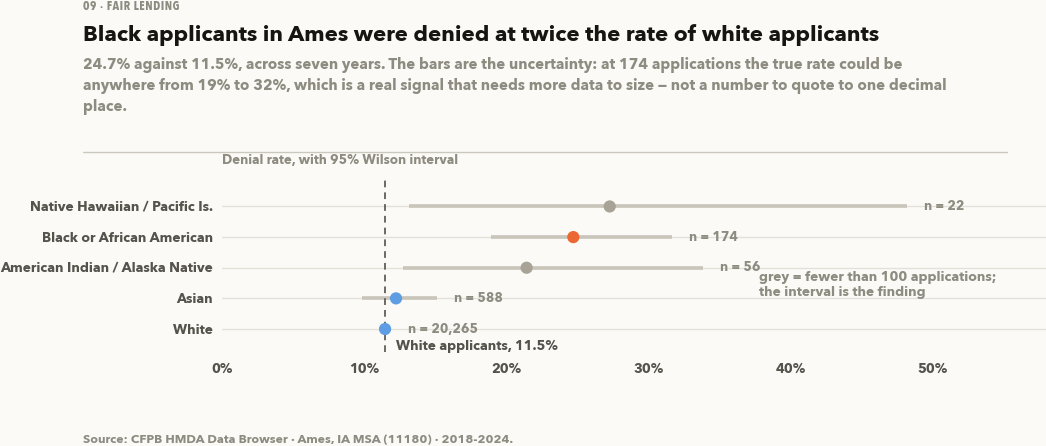

In [5]:
shown = by_race[~by_race["derived_race"].isin(NOT_A_GROUP)].copy()
shown = shown[shown["n"] >= 20].sort_values("denial_rate")
labels = [s.replace("Native Hawaiian or Other Pacific Islander", "Native Hawaiian / Pacific Is.")
           .replace("American Indian or Alaska Native", "American Indian / Alaska Native")
           .replace("Black or African American", "Black or African American")
          for s in shown["derived_race"]]
y = np.arange(len(shown))
reference_rate = float(by_race.set_index("derived_race").loc["White", "denial_rate"])

fig, ax = plt.subplots(figsize=(9.8, 4.6))
colors = [CONTEXT_DARK if n < MIN_GROUP_FOR_MODEL else
          (CONTRAST if r > reference_rate * 1.3 else SUBJECT_FILL)
          for r, n in zip(shown["denial_rate"], shown["n"])]
ax.errorbar(shown["denial_rate"], y,
            xerr=[shown["denial_rate"] - shown["ci_low"],
                  shown["ci_high"] - shown["denial_rate"]],
            fmt="none", ecolor=CONTEXT, elinewidth=2.4, capsize=0, zorder=1)
ax.scatter(shown["denial_rate"], y, s=64, c=colors, zorder=3, linewidths=0)
ax.set_yticks(y, labels)
ax.xaxis.set_major_formatter(pct)
ax.set_xlim(0, 0.58)
ax.set_ylim(-0.75, len(shown) - 0.15)
# The reference is labelled inside the panel: axis_note already owns the strip above
# the axes, and two annotations there collide.
ax.axvline(reference_rate, color=INK_SECONDARY, lw=1.1, zorder=2,
           linestyle=(0, (4, 3)))
annotate(ax, reference_rate, -0.55, f"White applicants, {reference_rate:.1%}",
         color=INK_SECONDARY, ha="left")
for yi, (r, n) in enumerate(zip(shown["denial_rate"], shown["n"])):
    ax.text(shown["ci_high"].iloc[yi] + 0.012, yi, f"n = {n:,}",
            va="center", fontsize=8.6, color=INK_MUTED)
axis_note(ax, "Denial rate, with 95% Wilson interval")
annotate(ax, 0.37, 1.45, "grey = fewer than 100 applications;\nthe interval is the finding",
         color=INK_MUTED, ha="left")
finish(fig, "Black applicants in Ames were denied at twice the rate of white applicants",
       "24.7% against 11.5%, across seven years. The bars are the uncertainty: at "
       "174 applications the true rate could be anywhere from 19% to 32%, which is a "
       "real signal that needs more data to size — not a number to quote to one "
       "decimal place.")
save(fig, "09_raw_denial_disparity")
plt.show()

In [6]:
pd.concat([
    by_ethnicity.assign(attribute="ethnicity").rename(columns={"derived_ethnicity": "group"}),
    by_sex.assign(attribute="sex").rename(columns={"derived_sex": "group"}),
])[["attribute", "group", "n", "denials", "denial_rate", "ci_low", "ci_high"]].round(4)

,attribute,group,n,denials,denial_rate,ci_low,ci_high
0,ethnicity,Not Hispanic or Latino,20405,2321,0.1137,0.1095,0.1182
1,ethnicity,Ethnicity Not Available,3999,478,0.1195,0.1098,0.1300
2,ethnicity,Hispanic or Latino,450,85,0.1889,0.1554,0.2276
3,ethnicity,Joint,346,57,0.1647,0.1294,0.2075
4,ethnicity,Free Form Text Only,3,2,0.6667,0.2077,0.9385
0,sex,Joint,11913,1046,0.0878,0.0829,0.0930
1,sex,Male,6623,936,0.1413,0.1331,0.1499
2,sex,Female,4107,671,0.1634,0.1524,0.1750
3,sex,Sex Not Available,2560,290,0.1133,0.1016,0.1261


Hispanic or Latino applicants: **18.9%** against **11.4%** for non-Hispanic. Female applicants: **11.7%** against **11.4%** for male, which is effectively no gap. The null result is reported alongside the others; a method that could only find disparities would not be informative.

## 3. What survives the controls

A raw gap is not evidence on its own. Groups differ in income, loan size, loan-to-value, debt-to-income and application year, and all of these legitimately affect a credit decision.

So denial is modelled with logistic regression on every underwriting factor HMDA records, and results are reported as odds ratios (1.0 means no difference). Applications missing any control are **dropped, not imputed**; imputing a borrower's LTV inside a discrimination model would mean inventing evidence.

In [7]:
race_adj = adjusted_disparity(apps, "derived_race", "White")
eth_adj = adjusted_disparity(apps, "derived_ethnicity", "Not Hispanic or Latino")
sex_adj = adjusted_disparity(apps, "derived_sex", "Male")

print("controls:", ", ".join(race_adj.attrs["controls"]))
print("omitted :", ", ".join(race_adj.attrs["omitted"]))
print(f"\nfitted on {race_adj.attrs['n_fitted']:,} applications "
      f"(McFadden pseudo-R2 {race_adj.attrs['pseudo_r2']:.3f}, "
      f"converged={race_adj.attrs['converged']})")
race_adj.round(3)

controls: log income, log loan amount, LTV, DTI band, loan purpose, lien status, occupancy, year
omitted : credit score, assets and reserves, employment history, property condition

fitted on 17,495 applications (McFadden pseudo-R2 0.217, converged=True)


,group,n_total,odds_ratio,ci_low,ci_high,p_value,reliable,e_value,e_value_ci
0,Asian,509,1.573,1.126,2.199,0.008,True,2.523,1.503
1,Black or African American,150,1.978,1.238,3.161,0.004,True,3.369,1.780
2,Other minority (pooled),72,2.606,1.392,4.882,0.003,False,4.653,2.130


  saved reports/figures/09_adjusted_disparity.png


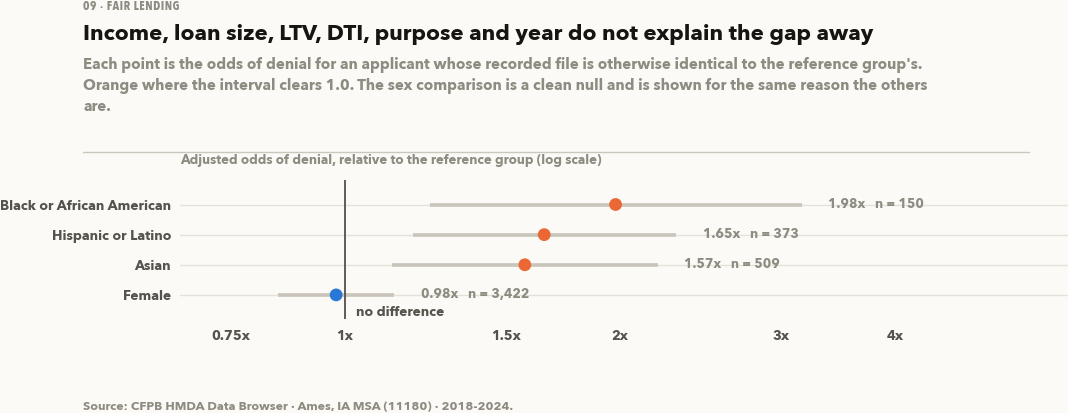

In [8]:
forest = pd.concat([
    race_adj.assign(attribute="race"),
    eth_adj.assign(attribute="ethnicity"),
    sex_adj.assign(attribute="sex"),
], ignore_index=True)
forest = forest[forest["group"] != POOLED_LABEL].sort_values("odds_ratio")

y = np.arange(len(forest))
labels = [f"{g}" for g in forest["group"]]
colors = [STATUS["serious"] if lo > 1 else (CONTEXT_DARK if not ok else SUBJECT)
          for lo, ok in zip(forest["ci_low"], forest["reliable"])]

fig, ax = plt.subplots(figsize=(10.0, 4.3))
ax.errorbar(forest["odds_ratio"], y,
            xerr=[forest["odds_ratio"] - forest["ci_low"],
                  forest["ci_high"] - forest["odds_ratio"]],
            fmt="none", ecolor=CONTEXT, elinewidth=2.4, capsize=0, zorder=1)
ax.scatter(forest["odds_ratio"], y, s=70, c=colors, zorder=3, linewidths=0)
ax.set_yticks(y, labels)
ax.set_xscale("log")
ax.set_xlim(0.66, 6.2)
ax.set_ylim(-0.8, len(forest) - 0.2)
ax.set_xticks([0.75, 1.0, 1.5, 2.0, 3.0, 4.0])
ax.xaxis.set_major_formatter(lambda v, _: f"{v:g}x")
# A log axis ships minor ticks labelled "6 x 10^-1", which is scientific notation
# nobody asked for sitting under the category labels.
ax.xaxis.set_minor_formatter(NullFormatter())
ax.tick_params(axis="x", which="minor", length=0)
ax.axvline(1.0, color=INK_SECONDARY, lw=1.2, zorder=2)
for yi, (orv, hi, n) in enumerate(zip(forest["odds_ratio"], forest["ci_high"],
                                      forest["n_total"])):
    ax.text(hi * 1.07, yi, f"{orv:.2f}x   n = {n:,}", va="center",
            fontsize=8.6, color=INK_MUTED)
axis_note(ax, "Adjusted odds of denial, relative to the reference group (log scale)")
annotate(ax, 1.0, -0.58, "no difference", color=INK_SECONDARY, ha="left")
finish(fig, "Income, loan size, LTV, DTI, purpose and year do not explain the gap away",
       "Each point is the odds of denial for an applicant whose recorded file is "
       "otherwise identical to the reference group's. Orange where the interval "
       "clears 1.0. The sex comparison is a clean null and is shown for the same "
       "reason the others are.")
save(fig, "09_adjusted_disparity")
plt.show()

Holding the recorded file constant, a Black applicant's odds of denial are **1.98×** a white applicant's (95% CI 1.24–3.16, p = 0.004). Hispanic or Latino, **1.65×** (1.19–2.30). Asian, **1.57×** (1.13–2.20). Female versus male: **0.98×**, indistinguishable from no difference.

These figures need the qualification in §4 before they can be interpreted.

## 4. The missing variable, and how much it would have to matter

HMDA does not record credit score. Credit score is the strongest single predictor of mortgage denial, and in the United States it correlates with race for reasons unrelated to any individual lender's conduct. The obvious objection to every number in §3 is that the variable that actually explains the gap has been omitted, making it a confounder.

Acknowledging the limitation does not say whether the objection is plausible. The E-value does.

An E-value is the minimum strength of association, with both the applicant's group and denial and over and above every control already in the model, that an unmeasured confounder would need to reduce the observed result to nothing.

In [9]:
sens = forest[["attribute", "group", "odds_ratio", "ci_low", "ci_high",
               "e_value", "e_value_ci", "reliable"]].copy()
sens = sens.sort_values("odds_ratio", ascending=False)
sens.round(3)

,attribute,group,odds_ratio,ci_low,ci_high,e_value,e_value_ci,reliable
1,race,Black or African American,1.978,1.238,3.161,3.369,1.780,True
3,ethnicity,Hispanic or Latino,1.652,1.186,2.302,2.690,1.655,True
0,race,Asian,1.573,1.126,2.199,2.523,1.503,True
4,sex,Female,0.978,0.844,1.132,1.176,1.000,True


  saved reports/figures/09_evalue_sensitivity.png


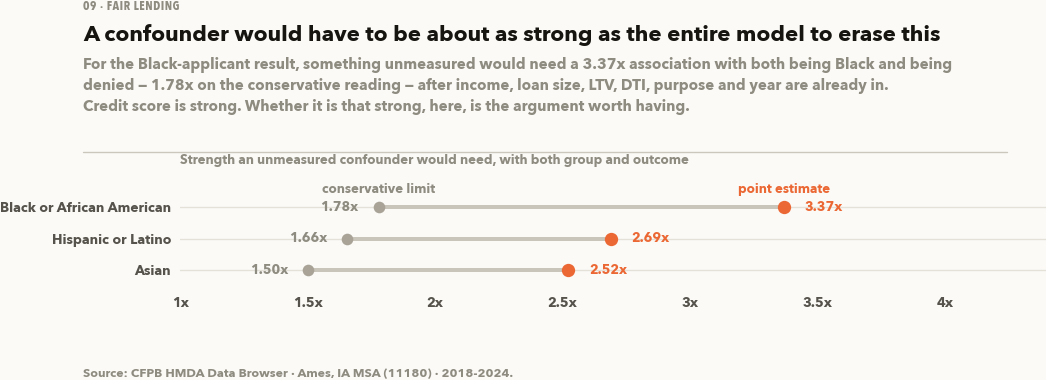

In [10]:
show = sens[sens["odds_ratio"] > 1].sort_values("e_value")
y = np.arange(len(show))

fig, ax = plt.subplots(figsize=(9.8, 4.0))
ax.hlines(y, show["e_value_ci"], show["e_value"], color=CONTEXT, lw=2.6, zorder=1)
ax.scatter(show["e_value_ci"], y, s=58, c=CONTEXT_DARK, zorder=3, linewidths=0)
ax.scatter(show["e_value"], y, s=76, c=CONTRAST, zorder=3, linewidths=0)
ax.set_yticks(y, list(show["group"]))
ax.set_xlim(1.0, 4.4)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:g}x")
for yi, (lo, hi) in enumerate(zip(show["e_value_ci"], show["e_value"])):
    ax.text(hi + 0.08, yi, f"{hi:.2f}x", va="center", fontsize=8.8, color=CONTRAST)
    ax.text(lo - 0.08, yi, f"{lo:.2f}x", va="center", ha="right",
            fontsize=8.8, color=INK_MUTED)
# Direct labels on the top row rather than a legend: axis_note already owns the
# strip above the axes, and a legend box placed there lands on top of it.
top = len(show) - 1
ax.set_ylim(-0.5, top + 0.85)
ax.text(show["e_value"].iloc[top], top + 0.34, "point estimate", ha="center",
        va="bottom", fontsize=8.6, color=CONTRAST, fontweight="demibold")
ax.text(show["e_value_ci"].iloc[top], top + 0.34, "conservative limit", ha="center",
        va="bottom", fontsize=8.6, color=INK_MUTED)
axis_note(ax, "Strength an unmeasured confounder would need, with both group and outcome")
finish(fig, "A confounder would have to be about as strong as the entire model to erase this",
       "For the Black-applicant result, something unmeasured would need a 3.37x "
       "association with both being Black and being denied — 1.78x on the "
       "conservative reading — after income, loan size, LTV, DTI, purpose and year "
       "are already in. Credit score is strong. Whether it is that strong, here, is "
       "the argument worth having.")
save(fig, "09_evalue_sensitivity")
plt.show()

**What this does and does not establish.** The E-value turns an open objection into a quantified one. It does not prove discrimination, and nothing in this notebook does: a lender's file contains information this one does not, and disparate treatment is a legal finding that requires evidence of conduct.

What it establishes is narrower and still useful. The disparity is **not fragile**; a weak confounder would not erase it. Any explanation resting on credit score has to argue that credit score carries roughly a 1.8-fold association with both race and denial *beyond* income, loan size, LTV, DTI, purpose and year, and that claim can now be evaluated directly.

This matches what the interagency AVM rule's fifth factor asks for: a documented, reproducible test with its limits stated, rather than a verdict.

## 5. Collateral: where this meets the valuation model

A denial carries up to four reasons. One of them is the house.

  saved reports/figures/09_denial_reasons.png


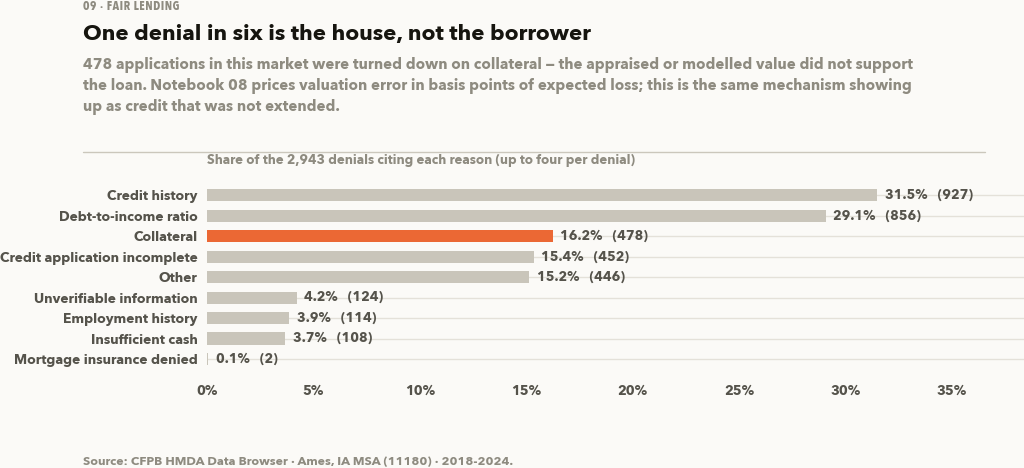

In [11]:
mix = denial_reason_mix(apps)
order = mix.sort_values("share")
colors = [CONTRAST if r == "Collateral" else CONTEXT for r in order["reason"]]

fig, ax = plt.subplots(figsize=(9.6, 4.8))
bars = ax.barh(np.arange(len(order)), order["share"], color=colors, height=0.6)
ax.set_yticks(np.arange(len(order)), order["reason"])
ax.xaxis.set_major_formatter(pct)
bar_labels(ax, bars, [f"{s:.1%}   ({n:,})" for s, n in zip(order["share"], order["denials"])])
ax.margins(x=0.22)
axis_note(ax, f"Share of the {int(apps['denied'].sum()):,} denials citing each reason "
              "(up to four per denial)")
finish(fig, "One denial in six is the house, not the borrower",
       "478 applications in this market were turned down on collateral — the "
       "appraised or modelled value did not support the loan. Notebook 08 prices "
       "valuation error in basis points of expected loss; this is the same mechanism "
       "showing up as credit that was not extended.")
save(fig, "09_denial_reasons")
plt.show()

**478 denials on collateral, 16.2% of all denials.** This is the valuation-quality question seen from the applicant's side.

Notebook 08 measures what valuation error costs a lender: marking the same book at the conservative end of the AVM's own interval raises expected loss by 85%. This measures what it costs an applicant: the loan does not happen. Both depend on how much confidence can be placed in a value attached to a house, and a bank that counts only the first sees half of the cost.

It also links valuation precision to access. Notebook 04 finds the valuation least precise at the cheap end of the market, with an over-valuation of about 2–3% there. At loan level imprecision cuts both ways (an over-stated value makes a loan look safer than it is, an under-stated one produces a collateral denial), and applicants buying where valuations are least certain are most exposed to both.

## 6. The loan book this project assumed, against the one that exists

Notebook 08 originates every loan at exactly 80% LTV on the AVM value, then shows that AVM error spreads the true LTV around that point. That isolates one effect cleanly. This section checks whether the premise holds.

In [12]:
ltv_table = ltv_distribution(apps)
print(f"n = {ltv_table.attrs['n']:,}   median {ltv_table.attrs['median']:.1f}%   "
      f"exactly 80.0%: {ltv_table.attrs['share_exactly_80']:.1%}")
ltv_table.round(4)

n = 21,153   median 80.0%   exactly 80.0%: 11.9%


,ltv_band,n,share
0,"(-0.001, 60.0]",3920,0.1853
1,"(60.0, 75.0]",3949,0.1867
2,"(75.0, 80.0]",4197,0.1984
3,"(80.0, 90.0]",3076,0.1454
4,"(90.0, 95.0]",2189,0.1035
5,"(95.0, 97.0]",1580,0.0747
6,"(97.0, 200.0]",2242,0.1060


  saved reports/figures/09_real_ltv_distribution.png


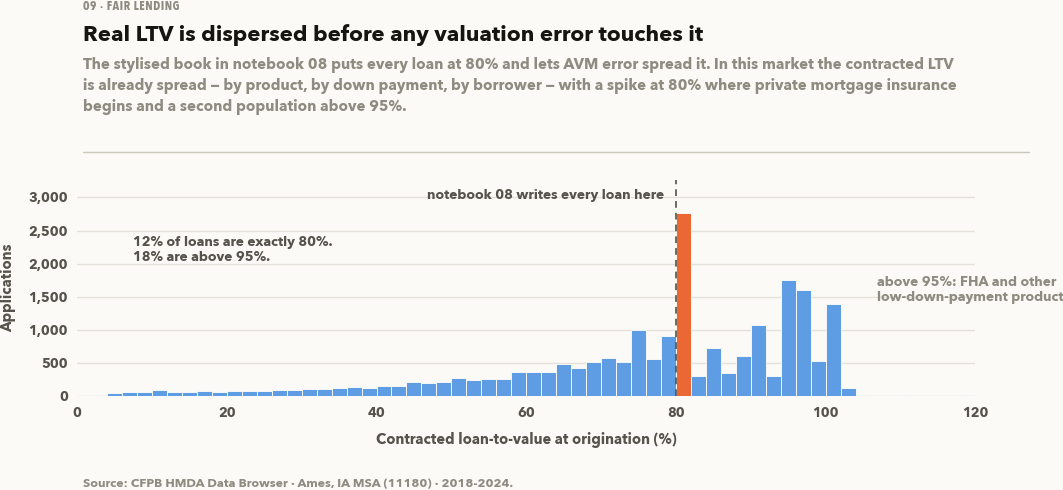

In [13]:
ltv = apps["loan_to_value_ratio"]
ltv = ltv[ltv.between(1, 120)]
# Both shares are computed on the same base -- applications with a reported LTV.
# Dividing one of them by all applications instead would quietly understate it.
share_80 = float((ltv == 80.0).mean())
share_above_95 = float((ltv > 95).mean())

fig, ax = plt.subplots(figsize=(10.0, 5.0))
counts, edges, patches = ax.hist(ltv, bins=np.arange(0, 122, 2),
                                 color=SUBJECT_FILL, edgecolor=SURFACE, linewidth=0.6)
for edge, patch in zip(edges[:-1], patches):
    if edge == 80:                       # the bin that holds exactly 80%
        patch.set_facecolor(CONTRAST)
ax.set_xlim(0, 120)
ax.set_ylim(0, counts.max() * 1.18)
ax.set_xlabel("Contracted loan-to-value at origination (%)")
ax.set_ylabel("Applications")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.axvline(80, color=INK_SECONDARY, lw=1.1, zorder=4, linestyle=(0, (4, 3)))
annotate(ax, 80, counts.max() * 1.10, "notebook 08 writes every loan here",
         color=INK_SECONDARY, ha="right", offset=(-8, 0))
annotate(ax, 106, counts[48], "above 95%: FHA and other\nlow-down-payment product",
         color=INK_MUTED, ha="left", offset=(4, 0))
annotate(ax, 6, counts.max() * 0.80,
         f"{share_80:.0%} of loans are exactly 80%.\n"
         f"{share_above_95:.0%} are above 95%.",
         color=INK_SECONDARY, ha="left")
finish(fig, "Real LTV is dispersed before any valuation error touches it",
       "The stylised book in notebook 08 puts every loan at 80% and lets AVM error "
       "spread it. In this market the contracted LTV is already spread — by product, "
       "by down payment, by borrower — with a spike at 80% where private mortgage "
       "insurance begins and a second population above 95%.")
save(fig, "09_real_ltv_distribution")
plt.show()

Only **11.9%** of loans sit at exactly 80%. 18.5% are at or below 60% LTV, and **18.1% are above 95%**, a population notebook 08 does not contain at all.

This does not invalidate notebook 08. A controlled book is the right instrument for isolating what AVM error alone does, and mixing in product variation would have confounded the effect being measured. It does limit the claim. The 88 bps base expected loss belongs to that constructed book, not to a real Ames loan book, and a real one carries a fatter right tail before any model error is added. The notebook 08 headline should therefore read: **AVM uncertainty adds 85% to expected loss on a book constructed to isolate it**, and a real book would start from a worse base.

## 7. Summary

| Finding | Consequence |
|---|---|
| Adjusted denial odds are 1.98x for Black and 1.65x for Hispanic applicants in this MSA | A measurable disparity exists in the lending market this AVM would serve |
| The E-value is 3.37 (1.78 at the confidence limit) | The result is not fragile to the missing credit score, and the strength that objection would need is now quantified |
| Female applicants show no disparity (0.98x) | The method can return a null result, which supports reading the non-null ones as real |
| 16.2% of denials cite collateral | Valuation quality affects access to credit as well as loss given default |
| Only 11.9% of real loans are at 80% LTV | Notebook 08's base expected loss is a property of its constructed book, and is stated as such |
| HMDA has no credit score | Every adjusted figure here is an upper bound on unexplained disparity. It is not a finding of discrimination, and this notebook does not make one |

In [14]:
# --- Carry the numbers forward -------------------------------------------------
# Every other notebook writes a summary JSON; this one did not.  That meant the
# published results page had to either omit fair lending or hand-copy its figures --
# and a hand-copied number is one that goes stale silently while still looking
# authoritative.  The page reads this file instead, on the same contract as every
# other section: if the analysis moves, the published number moves with it.
import json

from ames.config import PROCESSED


def _rate(table, column, group):
    row = table.loc[table[column] == group]
    return float(row["denial_rate"].iloc[0]) if len(row) else float("nan")


def _adjusted(table, group):
    """The fitted disparity for one group, with the honesty columns kept alongside.

    ``e_value`` and ``e_value_ci`` travel with the odds ratio deliberately: the odds
    ratio alone invites the reading this notebook spends section 5 refusing.
    """
    row = table.loc[table["group"] == group]
    if row.empty:
        return {}
    r = row.iloc[0]
    return {
        "odds_ratio": float(r["odds_ratio"]),
        "ci_low": float(r["ci_low"]),
        "ci_high": float(r["ci_high"]),
        "p_value": float(r["p_value"]),
        "e_value": float(r["e_value"]),
        "e_value_ci": float(r["e_value_ci"]),
        "n": int(r["n_total"]),
        "reliable": bool(r["reliable"]),
    }


_black = _rate(by_race, "derived_race", "Black or African American")
_white = _rate(by_race, "derived_race", "White")
_collateral = mix.loc[mix["reason"] == "Collateral"].iloc[0]

fairlending_summary = {
    "source": "CFPB HMDA modified LAR, Ames IA MSA",
    "msa": HMDA_MSA,
    "years": [int(min(HMDA_YEARS)), int(max(HMDA_YEARS))],
    "n_filings": int(len(hmda)),
    "n_decisioned": int(len(apps)),
    "n_denials": int(apps["denied"].sum()),
    "raw": {
        "black_denial_rate": _black,
        "white_denial_rate": _white,
        "black_white_ratio": _black / _white,
        "hispanic_denial_rate": _rate(
            by_ethnicity, "derived_ethnicity", "Hispanic or Latino"),
        "non_hispanic_denial_rate": _rate(
            by_ethnicity, "derived_ethnicity", "Not Hispanic or Latino"),
    },
    "adjusted": {
        "controls": list(race_adj.attrs["controls"]),
        "omitted": list(race_adj.attrs["omitted"]),
        "n_fitted": int(race_adj.attrs["n_fitted"]),
        "pseudo_r2": float(race_adj.attrs["pseudo_r2"]),
        "black": _adjusted(race_adj, "Black or African American"),
        "hispanic": _adjusted(eth_adj, "Hispanic or Latino"),
        "female": _adjusted(sex_adj, "Female"),
    },
    "collateral": {
        "denials": int(_collateral["denials"]),
        "share_of_denials": float(_collateral["share"]),
    },
    "ltv": {
        "share_exactly_80": share_80,
        "share_above_95": share_above_95,
        "median": float(ltv_table.attrs["median"]),
    },
    # Stated in the artifact, not only in the prose, so anything consuming this file
    # inherits the caveat rather than having to remember it.
    "caveat": ("HMDA records no credit score. Every adjusted figure is an upper bound "
               "on unexplained disparity, not a finding of discrimination."),
}

(PROCESSED / "fairlending_summary.json").write_text(
    json.dumps(fairlending_summary, indent=2) + "\n")
print(json.dumps(fairlending_summary, indent=2))

{
  "source": "CFPB HMDA modified LAR, Ames IA MSA",
  "msa": "11180",
  "years": [
    2018,
    2024
  ],
  "n_filings": 32926,
  "n_decisioned": 25203,
  "n_denials": 2943,
  "raw": {
    "black_denial_rate": 0.2471264367816092,
    "white_denial_rate": 0.11472982975573649,
    "black_white_ratio": 2.1539859102706713,
    "hispanic_denial_rate": 0.18888888888888888,
    "non_hispanic_denial_rate": 0.11374663072776281
  },
  "adjusted": {
    "controls": [
      "log income",
      "log loan amount",
      "LTV",
      "DTI band",
      "loan purpose",
      "lien status",
      "occupancy",
      "year"
    ],
    "omitted": [
      "credit score",
      "assets and reserves",
      "employment history",
      "property condition"
    ],
    "n_fitted": 17495,
    "pseudo_r2": 0.21701421213693017,
    "black": {
      "odds_ratio": 1.9779422938602074,
      "ci_low": 1.237567440698351,
      "ci_high": 3.161246481754012,
      "p_value": 0.004359036338638517,
      "e_value": 3.3687